# ATAG Waypoint 2050 (3rd edition, light) - Scenario S0

The 3rd edition has no S0, so this reference scenario is built from the `_a_r_m`
publication notebook, which models a single **generic SAF** under regional (RefuelEU /
US) blending policies. The `_a_r_m` notebook runs a 20-region **multi-regional** process;
here we run a single **global** process instead.

## Where each input comes from

| Input group | Source |
| --- | --- |
| **Traffic** | 3rd edition full **S1** (central traffic growth) - `s1_inputs.json` |
| **Efficiency** | 3rd edition full **T2** technology variant (energy-per-ASK gains) - `t2_inputs.json` |
| **Operations** | operations final gain = **3** (kept from S1; S1/S2 light use 6) |
| **SAF** | **aggregated** generic-SAF fuel policy across all 20 `_a_r_m` regions (global effective share + energy-weighted emission factor) |
| **Offsets** | 3rd edition full **S1** carbon-offset parameters |

The SAF aggregation and the multi-region -> single global conversion are done by
`aeromaps.utils.single_region.aggregate_regions_to_single_process`.

## Build the S0 demand inputs

Traffic + operations (final gain 3) + offsets come from 3rd-edition S1; the aircraft
**efficiency** (energy-per-ASK gains) is overridden with the 3rd-edition **T2** values.

In [1]:
import json

FULL = "../3rd_edition_full/data_inputs"

with open(f"{FULL}/s1_inputs.json") as f:
    s0_inputs = json.load(f)   # traffic, load factor, operations (=3), offsets
with open(f"{FULL}/t2_inputs.json") as f:
    t2_inputs = json.load(f)   # technology variant 2

# Efficiency: adopt T2 energy-per-ASK gain trajectories (short/medium/long range).
EFFICIENCY_KEYS = [
    "energy_per_ask_short_range_dropin_fuel_gain_reference_years",
    "energy_per_ask_short_range_dropin_fuel_gain_reference_years_values",
    "energy_per_ask_medium_range_dropin_fuel_gain_reference_years",
    "energy_per_ask_medium_range_dropin_fuel_gain_reference_years_values",
    "energy_per_ask_long_range_dropin_fuel_gain_reference_years",
    "energy_per_ask_long_range_dropin_fuel_gain_reference_years_values",
]
for key in EFFICIENCY_KEYS:
    s0_inputs[key] = t2_inputs[key]

# Operations final gain stays 3 (inherited from S1).
assert s0_inputs["operations_gain_reference_years_values"] == [0, 3]

with open("data_inputs/s0_inputs.json", "w") as f:
    json.dump(s0_inputs, f, indent=4)
print("Wrote data_inputs/s0_inputs.json (traffic+operations+offsets from S1, efficiency from T2)")

Wrote data_inputs/s0_inputs.json (traffic+operations+offsets from S1, efficiency from T2)


## Build the global process with an aggregated SAF policy

Every `_a_r_m` region is computed once; their heterogeneous SAF policies (EU 70% share,
US quantity mandate, 12 regions with no SAF, ...) are aggregated into a single global
effective SAF share and an energy-weighted emission factor, then run globally on the S0
demand and the top-down model chain (`config_s0_base.yaml`). This computes 20 regional
processes, so it takes a little longer than S1/S2.

In [2]:
%matplotlib widget
from aeromaps.utils.single_region import aggregate_regions_to_single_process

process = aggregate_regions_to_single_process(
    configuration_file="../../../publications/_a_r_m/regionalisation_all_regions.yaml",
    output_config="config_files/config_s0.yaml",
    output_energy_file="data_inputs/s0_energy.yaml",
    demand_override="data_inputs/s0_inputs.json",
    standards_override="config_files/config_s0_base.yaml",
    fuel_carrier="generic_saf",
    reference_region="EU_DOM",
    output_json="data_outputs/s0.json",
)
print("Process type:", type(process).__name__)

C:\Users\i.costa-alves\Documents\Kodigus\aeromaps\AeroMAPS\aeromaps\models\air_transport\aircraft_fleet_and_operations\fleet\fleet_model.py:911: UserWarning: Warning Message - Fleet Model: Short Range Aircraft: Average initial short-range fleet energy per ASK is higher than default energy per ASK for the old reference aircraft - AeroMAPS is using initial short-range fleet energy per ASK as old aircraft energy performances. Recent reference aircraft is introduced on first prospective year
  warnings.warn(


C:\Users\i.costa-alves\Documents\Kodigus\aeromaps\AeroMAPS\aeromaps\models\air_transport\aircraft_fleet_and_operations\fleet\fleet_model.py:1018: UserWarning: Warning Message - Fleet Model: long Range Aircraft: Average initial long-range fleet energy per ASK is higher than default energy per ASK for the old reference aircraft - AeroMAPS is using initial long-range fleet energy per ASK as old aircraft energy performances. Recent reference aircraft is introduced on first prospective year
  warnings.warn(


C:\Users\i.costa-alves\Documents\Kodigus\aeromaps\AeroMAPS\aeromaps\models\air_transport\aircraft_fleet_and_operations\fleet\fleet_model.py:966: UserWarning: Warning Message - Fleet Model: medium Range Aircraft: Average initial medium-range fleet energy per ASK is higher than default energy per ASK for the old reference aircraft - AeroMAPS is using initial medium-range fleet energy per ASK as old aircraft energy performances. Recent reference aircraft is introduced on first prospective year
  warnings.warn(


C:\Users\i.costa-alves\Documents\Kodigus\aeromaps\AeroMAPS\aeromaps\models\air_transport\aircraft_fleet_and_operations\fleet\fleet_model.py:966: UserWarning: Warning Message - Fleet Model: medium Range Aircraft: Average initial medium-range fleet energy per ASK is higher than default energy per ASK for the old reference aircraft - AeroMAPS is using initial medium-range fleet energy per ASK as old aircraft energy performances. Recent reference aircraft is introduced on first prospective year
  warnings.warn(


C:\Users\i.costa-alves\Documents\Kodigus\aeromaps\AeroMAPS\aeromaps\models\air_transport\aircraft_fleet_and_operations\fleet\fleet_model.py:1018: UserWarning: Warning Message - Fleet Model: long Range Aircraft: Average initial long-range fleet energy per ASK is higher than default energy per ASK for the old reference aircraft - AeroMAPS is using initial long-range fleet energy per ASK as old aircraft energy performances. Recent reference aircraft is introduced on first prospective year
  warnings.warn(


...

C:\Users\i.costa-alves\Documents\Kodigus\aeromaps\AeroMAPS\aeromaps\models\yaml_interpolator.py:140: UserWarning: 
[Interpolation Model: generic_saf_mandate_quantity Warning]
The first reference year (2025) differs from the prospection start year (2020).
Interpolation will begin at the first reference year.
  warnings.warn(


C:\Users\i.costa-alves\Documents\Kodigus\aeromaps\AeroMAPS\aeromaps\models\yaml_interpolator.py:140: UserWarning: 
[Interpolation Model: generic_saf_mandate_quantity Warning]
The first reference year (2025) differs from the prospection start year (2020).
Interpolation will begin at the first reference year.
  warnings.warn(


C:\Users\i.costa-alves\Documents\Kodigus\aeromaps\AeroMAPS\aeromaps\models\air_transport\aircraft_fleet_and_operations\fleet\fleet_model.py:966: UserWarning: Warning Message - Fleet Model: medium Range Aircraft: Average initial medium-range fleet energy per ASK is higher than default energy per ASK for the old reference aircraft - AeroMAPS is using initial medium-range fleet energy per ASK as old aircraft energy performances. Recent reference aircraft is introduced on first prospective year
  warnings.warn(


Process type:

AeroMAPSProcess

## Compute

In [3]:
process.compute()
process.write_json()
print("Global aggregated SAF share (%):")
print(process.data["vector_outputs"]["generic_saf_mandate_share"].loc[[2025, 2030, 2040, 2050]])

C:\Users\i.costa-alves\Documents\Kodigus\aeromaps\AeroMAPS\aeromaps\models\base.py:220: UserWarning: 
[Interpolation Model: passenger_aircraft_efficiency_simple_shares Warning]
The first reference year (2019) differs from the prospection start year (2020).
Interpolation will begin at the first reference year.
  warnings.warn(


C:\Users\i.costa-alves\Documents\Kodigus\aeromaps\AeroMAPS\aeromaps\models\base.py:220: UserWarning: 
[Interpolation Model: passenger_aircraft_efficiency_simple_shares Warning]
The first reference year (2019) differs from the prospection start year (2020).
Interpolation will begin at the first reference year.
  warnings.warn(


C:\Users\i.costa-alves\Documents\Kodigus\aeromaps\AeroMAPS\aeromaps\models\base.py:220: UserWarning: 
[Interpolation Model: passenger_aircraft_efficiency_simple_shares Warning]
The first reference year (2019) differs from the prospection start year (2020).
Interpolation will begin at the first reference year.
  warnings.warn(


Global aggregated SAF share (%):

2025   0.366758
2030    4.01675
2040    12.0185
2050    25.8671
Name: generic_saf_mandate_share, dtype: float64

## Results

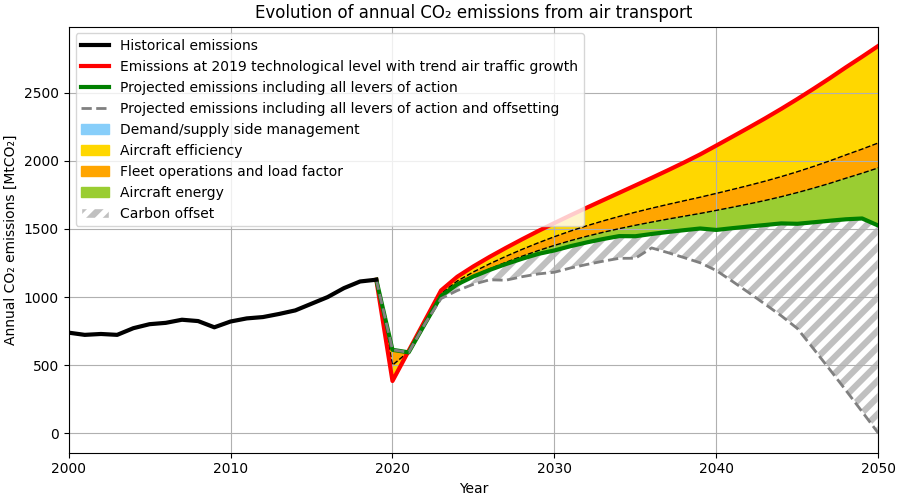

In [4]:
process.plot("air_transport_co2_emissions")

interactive(children=(Dropdown(description='Aircraft Type:', options=('dropin_fuel', 'All Types'), value='drop…

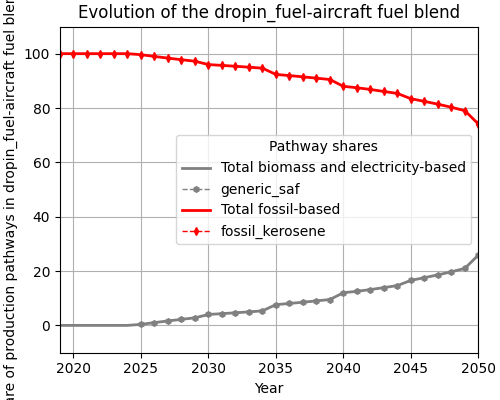

In [5]:
process.plot("fuel_shares")

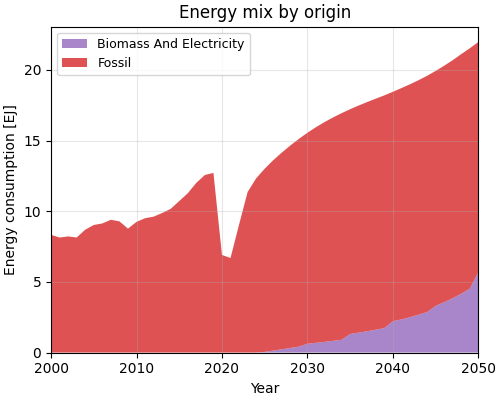

In [6]:
process.plot("energy_mix")